# 08 — Citation Parsing Analysis & Parser Design

Análise exploratória de parsing estrutural usando exclusivamente spans-oráculo. Detection, existência no corpus e resolução ficam deliberadamente fora desta etapa.

## 1. Dataset e oracle spans

Cada `trecho` é recuperado diretamente de `texto[inicio:fim]`. Os rótulos de classificação são preservados apenas para o cruzamento analítico final; não entram em reconhecimento de família ou parsing.

In [1]:
from __future__ import annotations

import hashlib
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', 120)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
TEXT_DIR, GOLDENSET_PATH, DB_PATH = DATASET_DIR / 'txt', DATASET_DIR / 'goldenset.xlsx', DATASET_DIR / 'desafio1_bracis.db'

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

db_sha_before = sha256_file(DB_PATH)
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl').reset_index(names='gold_idx')
gold['nivel'] = 'N' + gold['nivel'].astype(str).str.removeprefix('N')
gold['inicio'], gold['fim'] = gold['inicio'].astype(int), gold['fim'].astype(int)
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
gold['oracle_span'] = gold.apply(lambda row: texts[row.documento_id][row.inicio:row.fim], axis=1)
gold['trecho_esperado'] = gold['trecho'].astype(str).str.replace(r'\n', '\n', regex=False)
assert len(texts) == 26 and len(gold) == 225 and gold.oracle_span.eq(gold.trecho_esperado).all()
assert gold.nivel.value_counts().to_dict() == {'N1': 116, 'N2': 109}
assert gold.tipo.value_counts().to_dict() == {'jurisprudencia': 186, 'lei': 39}
assert gold.classificacao.value_counts().to_dict() == {'real': 96, 'incompleta': 65, 'inventada': 64}
print('SHA-256 antes:', db_sha_before)
display(gold[['nivel', 'tipo', 'classificacao']].value_counts().rename('quantidade').reset_index())


SHA-256 antes: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71


,nivel,tipo,classificacao,quantidade
0,N1,jurisprudencia,real,44
1,N2,jurisprudencia,real,38
2,N2,jurisprudencia,incompleta,29
3,N1,jurisprudencia,inventada,26
4,N1,jurisprudencia,incompleta,25
5,N2,jurisprudencia,inventada,24
6,N1,lei,real,8
7,N2,lei,inventada,8
8,N1,lei,incompleta,7
9,N1,lei,inventada,6


## 2. Reconhecimento de família e parsers experimentais

O dispatch começa pela família. Parsers legais têm precedência para spans legais, portanto artigo, parágrafo, inciso e número de lei nunca são colocados no campo de processo. Normalização remove somente separadores; reparo OCR não é aplicado.

In [2]:
CNJ_PATTERN = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
SUMULA_PATTERN = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?(?P<number>\d+)', re.I)
ARTICLE_PATTERN = re.compile(r'\b(?:art(?:igo)?s?[.]?\s*)(?P<number>\d+(?:[.]\d+)*(?:[ºo]|-[A-Za-z])?)', re.I)
PARAGRAPH_PATTERN = re.compile(r'(?P<raw>§{1,2}\s*(?P<number>\d+(?:[ºo])?|único))', re.I)
INCISO_PATTERN = re.compile(r'\binciso\s+(?P<number>[IVXLCDM]+)\b', re.I)
ALINEA_PATTERN = re.compile(r'\bal[ií]nea\s+(?P<value>[a-z])\b', re.I)
DIPLOMA_PATTERN = re.compile(r'\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo(?: Civil| Penal| de Processo Civil| de Processo Penal)?|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+[./-]?[\d./-]*|CLT|CPC|CPP|CC|CDC|CPM)\b', re.I)
LAW_NUMBER_PATTERN = re.compile(r'\bLei(?: Complementar)?\s*(?:n[ºo.]?\s*)?(?P<number>\d+[./-]?\d*)(?:/(?P<year>\d{4}))?', re.I)
TRIBUNAL_PATTERN = re.compile(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b', re.I)
PROCESS_CLASS_PATTERN = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
NUMBERED_CASE_PATTERN = re.compile(r'(?P<classe>(?:(?:AgInt|AgRg|EDcl|ED)\s+(?:no|n[oº.]+)\s+)?(?:AREsp|REsp|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Recurso\s+(?:Especial|Extraordin[aá]rio)|Agravo(?:\s+Regimental)?|Habeas\s+Corpus|Reclamaç[aã]o))\s*(?:n[ºo.]?\s*)?(?P<number>\d[\d.\-/ ]{2,}\d)(?:\s*(?P<uf>[-/]\s*[A-Z]{2}))?', re.I)
RELATOR_PATTERN = re.compile(r'\b(?:Rel\.?|Relator(?:a)?)\s*(?:Min\.?|Ministra|Ministro|Des\.?)?\s*(?P<name>[A-Z][A-Za-zÀ-ÿ .-]{2,})', re.I)
YEAR_PATTERN = re.compile(r'\b(?P<year>19\d{2}|20\d{2})\b')

TRIBUNAL_NORMALIZATION = {
    'STF': 'STF', 'SUPREMO TRIBUNAL FEDERAL': 'STF', 'STJ': 'STJ', 'SUPERIOR TRIBUNAL DE JUSTIÇA': 'STJ',
    'TSE': 'TSE', 'TRIBUNAL SUPERIOR ELEITORAL': 'TSE', 'TST': 'TST', 'TRIBUNAL SUPERIOR DO TRABALHO': 'TST',
    'STM': 'STM', 'SUPERIOR TRIBUNAL MILITAR': 'STM',
}

def family_for(text: str, citation_type: str) -> str:
    if citation_type == 'lei':
        return 'lei_dispositivo_com_diploma' if ARTICLE_PATTERN.search(text) and DIPLOMA_PATTERN.search(text) else ('lei_dispositivo_sem_diploma' if ARTICLE_PATTERN.search(text) else 'lei_referencia_geral')
    if SUMULA_PATTERN.search(text): return 'sumula_numerada'
    if CNJ_PATTERN.search(text): return 'processo_cnj'
    if PROCESS_CLASS_PATTERN.search(text) and re.search(r'\d', text): return 'processo_ou_recurso_numerado'
    if TRIBUNAL_PATTERN.search(text) and (YEAR_PATTERN.search(text) or RELATOR_PATTERN.search(text)): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'

def digits(value: str | None) -> str | None:
    return re.sub(r'\D', '', value) if value else None

def extract_tribunal(text: str) -> tuple[str | None, str | None, str]:
    match = TRIBUNAL_PATTERN.search(text)
    if not match: return None, None, 'unknown'
    raw = match.group(0)
    return raw, TRIBUNAL_NORMALIZATION[raw.upper()], 'explicit'

def blank(text: str, family: str, citation_type: str) -> dict:
    return {'tribunal_raw': None, 'tribunal': None, 'tribunal_source': 'unknown', 'classe_raw': None, 'numero_raw': None, 'numero_normalizado': None, 'numero_family': None, 'uf_raw': None, 'uf': None, 'sumula_numero_raw': None, 'sumula_numero': None, 'artigo_raw': None, 'artigo': None, 'paragrafo_raw': None, 'paragrafo': None, 'inciso': None, 'alinea': None, 'diploma_raw': None, 'diploma_normalizado': None, 'law_number_raw': None, 'law_number': None, 'law_year': None, 'relator_raw': None, 'ano': None, 'year_source': None, 'numeric_types': ()}

def parse_cnj(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); match = CNJ_PATTERN.search(text)
    if match:
        result.update(numero_raw=match.group(0), numero_normalizado=digits(match.group(0)), numero_family='cnj', numeric_types=('cnj',))
    result['tribunal_raw'], result['tribunal'], result['tribunal_source'] = extract_tribunal(text)
    return result

def parse_numbered_case(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); match = NUMBERED_CASE_PATTERN.search(text)
    class_match = PROCESS_CLASS_PATTERN.search(text)
    if class_match: result['classe_raw'] = class_match.group(0)
    if match:
        uf_raw = match.group('uf')
        result.update(classe_raw=match.group('classe'), numero_raw=match.group('number'), numero_normalizado=digits(match.group('number')), numero_family='recurso_number' if re.search(r'REsp|AREsp|Recurso', match.group('classe'), re.I) else 'case_number', uf_raw=uf_raw, uf=uf_raw[-2:] if uf_raw else None, numeric_types=('recurso_number' if re.search(r'REsp|AREsp|Recurso', match.group('classe'), re.I) else 'case_number',))
    result['tribunal_raw'], result['tribunal'], result['tribunal_source'] = extract_tribunal(text)
    return result

def parse_sumula(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); match = SUMULA_PATTERN.search(text)
    if match: result.update(sumula_numero_raw=match.group('number'), sumula_numero=digits(match.group('number')), numeric_types=('sumula_number',))
    result['tribunal_raw'], result['tribunal'], result['tribunal_source'] = extract_tribunal(text)
    return result

def parse_contextual(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); result['tribunal_raw'], result['tribunal'], result['tribunal_source'] = extract_tribunal(text)
    relator, year = RELATOR_PATTERN.search(text), YEAR_PATTERN.search(text)
    if relator: result['relator_raw'] = relator.group(0)
    if year: result.update(ano=year.group('year'), year_source='contextual', numeric_types=('year',))
    return result

def parse_legal(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); article, paragraph, inciso, alinea, diploma, law = ARTICLE_PATTERN.search(text), PARAGRAPH_PATTERN.search(text), INCISO_PATTERN.search(text), ALINEA_PATTERN.search(text), DIPLOMA_PATTERN.search(text), LAW_NUMBER_PATTERN.search(text)
    if article: result.update(artigo_raw=article.group(0), artigo=digits(article.group('number').rstrip('ºo')))
    if paragraph: result.update(paragrafo_raw=paragraph.group('raw'), paragrafo=paragraph.group('number').rstrip('ºo'))
    if inciso: result['inciso'] = inciso.group('number').upper()
    if alinea: result['alinea'] = alinea.group('value').lower()
    if diploma: result.update(diploma_raw=diploma.group(0), diploma_normalizado=re.sub(r'\s+', ' ', diploma.group(0)).upper())
    if law: result.update(law_number_raw=law.group('number'), law_number=digits(law.group('number')), law_year=law.group('year'))
    numeric = []
    if result['artigo']: numeric.append('article_number')
    if result['paragrafo']: numeric.append('paragraph_number')
    if result['inciso']: numeric.append('inciso')
    if result['law_number']: numeric.append('law_number')
    if result['law_year']: numeric.append('year')
    result['numeric_types'] = tuple(numeric)
    return result

def parse_general(text: str, family: str, citation_type: str) -> dict:
    result = blank(text, family, citation_type); result['tribunal_raw'], result['tribunal'], result['tribunal_source'] = extract_tribunal(text)
    return result

PARSERS = {'processo_cnj': parse_cnj, 'processo_ou_recurso_numerado': parse_numbered_case, 'sumula_numerada': parse_sumula, 'jurisprudencia_tribunal_contextual': parse_contextual, 'jurisprudencia_referencia_geral': parse_general, 'lei_dispositivo_com_diploma': parse_legal, 'lei_dispositivo_sem_diploma': parse_legal, 'lei_referencia_geral': parse_legal}
gold['family'] = gold.apply(lambda row: family_for(row.oracle_span, row.tipo), axis=1)
parsed = pd.DataFrame([PARSERS[row.family](row.oracle_span, row.family, row.tipo) for row in gold.itertuples()])
analysis = pd.concat([gold.reset_index(drop=True), parsed], axis=1)
assert analysis.loc[analysis.tipo.eq('lei'), 'numero_normalizado'].isna().all(), 'números legais não podem ocupar numero_normalizado'
display(analysis.groupby(['family', 'nivel']).size().rename('total').reset_index())


,family,nivel,total
0,jurisprudencia_referencia_geral,N1,15
1,jurisprudencia_referencia_geral,N2,31
2,jurisprudencia_tribunal_contextual,N1,11
3,jurisprudencia_tribunal_contextual,N2,9
4,lei_dispositivo_com_diploma,N1,13
5,lei_dispositivo_com_diploma,N2,14
6,lei_dispositivo_sem_diploma,N1,1
7,lei_referencia_geral,N1,7
8,lei_referencia_geral,N2,4
9,processo_cnj,N1,17


## 3. Cobertura estrutural e tipos numéricos

Cobertura significa campo extraído quando é relevante para a família; `N/A` não representa falha. Presença explícita e extração são contadas separadamente, sem criar um gold estrutural inexistente.

,family,field,total,explicit_present,parsed,coverage
0,jurisprudencia_referencia_geral,tribunal,46,4.0,4.0,1.000
13,jurisprudencia_tribunal_contextual,tribunal,20,20.0,20.0,1.000
18,jurisprudencia_tribunal_contextual,relator_raw,20,20.0,20.0,1.000
19,jurisprudencia_tribunal_contextual,ano,20,20.0,20.0,1.000
33,lei_dispositivo_com_diploma,artigo,27,27.0,27.0,1.000
34,lei_dispositivo_com_diploma,paragrafo,27,1.0,1.0,1.000
35,lei_dispositivo_com_diploma,inciso,27,0.0,0.0,NaN
36,lei_dispositivo_com_diploma,alinea,27,0.0,0.0,NaN
37,lei_dispositivo_com_diploma,diploma_normalizado,27,27.0,27.0,1.000
38,lei_dispositivo_com_diploma,law_number,27,6.0,6.0,1.000


,family,total,N1,N2,tribunal,classe_raw,numero_normalizado,uf,sumula_numero,artigo,diploma_normalizado
0,jurisprudencia_referencia_geral,46,15,31,4,N/A,N/A,N/A,N/A,N/A,N/A
1,jurisprudencia_tribunal_contextual,20,11,9,20,N/A,N/A,N/A,N/A,N/A,N/A
2,lei_dispositivo_com_diploma,27,13,14,N/A,N/A,N/A,N/A,N/A,27,27
3,lei_dispositivo_sem_diploma,1,1,0,N/A,N/A,N/A,N/A,N/A,1,N/A
4,lei_referencia_geral,11,7,4,N/A,N/A,N/A,N/A,N/A,N/A,2
5,processo_cnj,25,17,8,7,N/A,25,N/A,N/A,N/A,N/A
6,processo_ou_recurso_numerado,85,46,39,7,85,61,53,N/A,N/A,N/A
7,sumula_numerada,10,6,4,7,N/A,N/A,N/A,10,N/A,N/A


,classe_raw,total,N1,N2
21,Rcl,18,15,3
22,Reclamação,15,6,9
23,Recurso Especial,8,5,3
19,REsp,7,5,2
7,AgInt no REsp,5,5,0
4,AgInt no ARESP,3,0,3
16,RCL,3,0,3
15,Habeas Corpus,3,1,2
17,RE,3,1,2
13,Agravo,2,2,0


,diploma_normalizado,total
1,CONSTITUIÇÃO,6
4,CÓDIGO,6
6,CÓDIGO DE PROCESSO CIVIL,3
0,CLT,3
11,LEI Nº 9.504/1997,2
2,CONSTITUIÇÃO FEDERAL,2
8,LEI COMPLEMENTAR Nº 64/1990,2
3,CPC,1
7,CÓDIGO PENAL,1
5,CÓDIGO CIVIL,1


,number_family,total,families
0,cnj,25,processo_cnj
1,case_number,27,processo_ou_recurso_numerado
2,recurso_number,34,processo_ou_recurso_numerado
3,sumula_number,10,sumula_numerada
4,article_number,28,"lei_dispositivo_com_diploma, lei_dispositivo_sem_diploma"
5,paragraph_number,1,lei_dispositivo_com_diploma
6,inciso,0,—
7,alinea,0,—
8,law_number,6,lei_dispositivo_com_diploma
9,year,24,"jurisprudencia_tribunal_contextual, lei_dispositivo_com_diploma"


,field,nivel,relevant_spans,parsed,coverage
0,tribunal,N1,95,21,0.221
1,tribunal,N2,91,24,0.264
2,numero_normalizado,N1,63,57,0.905
3,numero_normalizado,N2,47,29,0.617
4,sumula_numero,N1,6,6,1.000
5,sumula_numero,N2,4,4,1.000
6,artigo,N1,14,14,1.000
7,artigo,N2,14,14,1.000
8,diploma_normalizado,N1,20,14,0.700
9,diploma_normalizado,N2,18,15,0.833


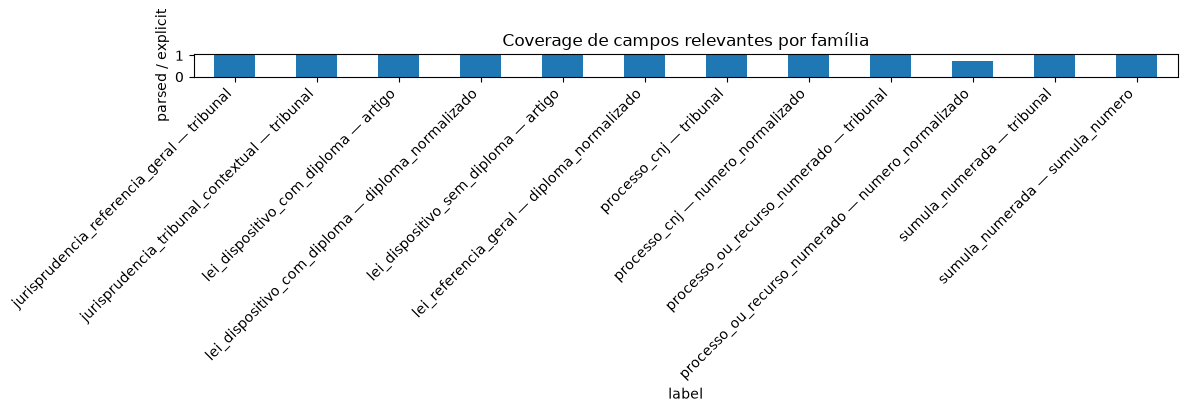

In [3]:
FIELD_RELEVANCE = {
 'processo_cnj': ('tribunal', 'numero_normalizado'), 'processo_ou_recurso_numerado': ('tribunal', 'classe_raw', 'numero_normalizado', 'uf'),
 'sumula_numerada': ('tribunal', 'sumula_numero'), 'jurisprudencia_tribunal_contextual': ('tribunal', 'relator_raw', 'ano'),
 'jurisprudencia_referencia_geral': ('tribunal',), 'lei_dispositivo_com_diploma': ('artigo', 'paragrafo', 'inciso', 'alinea', 'diploma_normalizado', 'law_number'),
 'lei_dispositivo_sem_diploma': ('artigo', 'paragrafo', 'inciso', 'alinea'), 'lei_referencia_geral': ('diploma_normalizado', 'law_number'),
}
PRESENT_PATTERNS = {'tribunal': TRIBUNAL_PATTERN, 'classe_raw': PROCESS_CLASS_PATTERN, 'numero_normalizado': NUMBERED_CASE_PATTERN, 'uf': re.compile(r'[-/]\s*[A-Z]{2}\b'), 'sumula_numero': SUMULA_PATTERN, 'relator_raw': RELATOR_PATTERN, 'ano': YEAR_PATTERN, 'artigo': ARTICLE_PATTERN, 'paragrafo': PARAGRAPH_PATTERN, 'inciso': INCISO_PATTERN, 'alinea': ALINEA_PATTERN, 'diploma_normalizado': DIPLOMA_PATTERN, 'law_number': LAW_NUMBER_PATTERN}
coverage_rows = []
for family, group in analysis.groupby('family'):
    for field in ('tribunal', 'classe_raw', 'numero_normalizado', 'uf', 'sumula_numero', 'relator_raw', 'ano', 'artigo', 'paragrafo', 'inciso', 'alinea', 'diploma_normalizado', 'law_number'):
        relevant = field in FIELD_RELEVANCE[family]
        pattern = CNJ_PATTERN if family == 'processo_cnj' and field == 'numero_normalizado' else (re.compile(r'\d') if family == 'processo_ou_recurso_numerado' and field == 'numero_normalizado' else PRESENT_PATTERNS[field])
        explicit = int(group.oracle_span.map(lambda span: bool(pattern.search(span))).sum()) if relevant else None
        extracted = int(group[field].notna().sum()) if relevant else None
        coverage_rows.append({'family': family, 'field': field, 'relevant': relevant, 'total': len(group), 'explicit_present': explicit, 'parsed': extracted, 'coverage': extracted / explicit if explicit else None})
coverage = pd.DataFrame(coverage_rows)
display(coverage.loc[coverage.relevant, ['family', 'field', 'total', 'explicit_present', 'parsed', 'coverage']].round(3))

wide_fields = {'processo_cnj': ('tribunal', 'numero_normalizado'), 'processo_ou_recurso_numerado': ('tribunal', 'classe_raw', 'numero_normalizado', 'uf'), 'sumula_numerada': ('tribunal', 'sumula_numero'), 'jurisprudencia_tribunal_contextual': ('tribunal', 'relator_raw', 'ano'), 'jurisprudencia_referencia_geral': ('tribunal',), 'lei_dispositivo_com_diploma': ('artigo', 'diploma_normalizado'), 'lei_dispositivo_sem_diploma': ('artigo',), 'lei_referencia_geral': ('diploma_normalizado',)}
family_structure = []
for family, group in analysis.groupby('family'):
    row = {'family': family, 'total': len(group), 'N1': int(group.nivel.eq('N1').sum()), 'N2': int(group.nivel.eq('N2').sum())}
    for field in ('tribunal', 'classe_raw', 'numero_normalizado', 'uf', 'sumula_numero', 'artigo', 'diploma_normalizado'):
        row[field] = int(group[field].notna().sum()) if field in wide_fields[family] else 'N/A'
    family_structure.append(row)
family_structure = pd.DataFrame(family_structure)
display(family_structure)
class_inventory = analysis.loc[analysis.family.eq('processo_ou_recurso_numerado') & analysis.classe_raw.notna()].groupby('classe_raw').agg(total=('gold_idx', 'size'), N1=('nivel', lambda values: (values == 'N1').sum()), N2=('nivel', lambda values: (values == 'N2').sum())).reset_index().sort_values('total', ascending=False)
diploma_inventory = analysis.loc[analysis.diploma_normalizado.notna()].groupby('diploma_normalizado').size().rename('total').reset_index().sort_values('total', ascending=False)
display(class_inventory); display(diploma_inventory)

numeric = analysis[['family', 'nivel', 'numeric_types']].explode('numeric_types').dropna(subset=['numeric_types']).groupby('numeric_types').agg(total=('family', 'size'), families=('family', lambda values: ', '.join(sorted(set(values))))).reset_index().rename(columns={'numeric_types': 'number_family'}).set_index('number_family').reindex(['cnj', 'case_number', 'recurso_number', 'sumula_number', 'article_number', 'paragraph_number', 'inciso', 'alinea', 'law_number', 'year', 'unrelated_number', 'unknown_numeric']).rename_axis('number_family').reset_index()
numeric['total'] = numeric['total'].fillna(0).astype(int); numeric['families'] = numeric['families'].fillna('—')
display(numeric)

level_coverage = []
for field in ('tribunal', 'numero_normalizado', 'sumula_numero', 'artigo', 'diploma_normalizado', 'relator_raw', 'ano'):
    for level, group in analysis.groupby('nivel'):
        relevant = group.family.map(lambda family: field in FIELD_RELEVANCE[family])
        level_coverage.append({'field': field, 'nivel': level, 'relevant_spans': int(relevant.sum()), 'parsed': int(group.loc[relevant, field].notna().sum()), 'coverage': group.loc[relevant, field].notna().mean() if relevant.any() else None})
level_coverage = pd.DataFrame(level_coverage)
display(level_coverage.round(3))

plot_fields = coverage.loc[coverage.relevant & coverage.field.isin(['numero_normalizado', 'sumula_numero', 'artigo', 'diploma_normalizado', 'tribunal'])].copy()
plot_fields['label'] = plot_fields.family + ' — ' + plot_fields.field
plot_fields.set_index('label')['coverage'].fillna(0).plot.bar(figsize=(12, 4), title='Coverage de campos relevantes por família', ylabel='parsed / explicit'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


## 4. Auditoria, falhas, proveniência e identificabilidade

Nenhuma ausência é transformada em erro: falhas abaixo significam que um sinal estrutural explícito foi observado mas o campo correspondente não foi extraído. Reparos OCR permanecem apenas como hipótese marcada.

,family,failure_type,quantidade
0,processo_ou_recurso_numerado,numero_normalizado_explicit_not_parsed,24.0
1,processo_ou_recurso_numerado,uf_explicit_not_parsed,10.0


,mecanismo,familias_afetadas,casos_afetados,impacto
0,newline_em_numero,jurisprudencia_referencia_geral,2,registrar para tolerância local futura; sem repair nesta análise
1,espaco_em_numero,jurisprudencia_referencia_geral,0,não observado por este indicador conservador
2,possivel_O0_l1_S5_em_numero,jurisprudencia_referencia_geral,0,não observado por este indicador conservador
3,S5_em_sumula,jurisprudencia_referencia_geral,1,registrar para tolerância local futura; sem repair nesta análise
4,rn_por_m,jurisprudencia_referencia_geral,0,não observado por este indicador conservador
5,newline_em_numero,jurisprudencia_tribunal_contextual,0,não observado por este indicador conservador
6,espaco_em_numero,jurisprudencia_tribunal_contextual,0,não observado por este indicador conservador
7,possivel_O0_l1_S5_em_numero,jurisprudencia_tribunal_contextual,0,não observado por este indicador conservador
8,S5_em_sumula,jurisprudencia_tribunal_contextual,0,não observado por este indicador conservador
9,rn_por_m,jurisprudencia_tribunal_contextual,0,não observado por este indicador conservador


,tribunal_source,quantidade
0,unknown,180
1,explicit,45


Inferência segura de tribunal: nenhuma aplicada. CNJ preserva o identificador, mas o segmento de justiça não foi promovido silenciosamente a um tribunal específico.


,searchability_profile,quantidade,familias
5,generic_reference,79,"jurisprudencia_referencia_geral, lei_referencia_geral, processo_ou_recurso_numerado"
1,case_identifier,61,processo_ou_recurso_numerado
6,legal_device_with_diploma,27,lei_dispositivo_com_diploma
2,cnj_identifier,25,processo_cnj
3,contextual_metadata,20,jurisprudencia_tribunal_contextual
8,sumula_with_tribunal,7,sumula_numerada
7,sumula_number_only,3,sumula_numerada
4,diploma_only,2,lei_referencia_geral
0,article_only,1,lei_dispositivo_sem_diploma


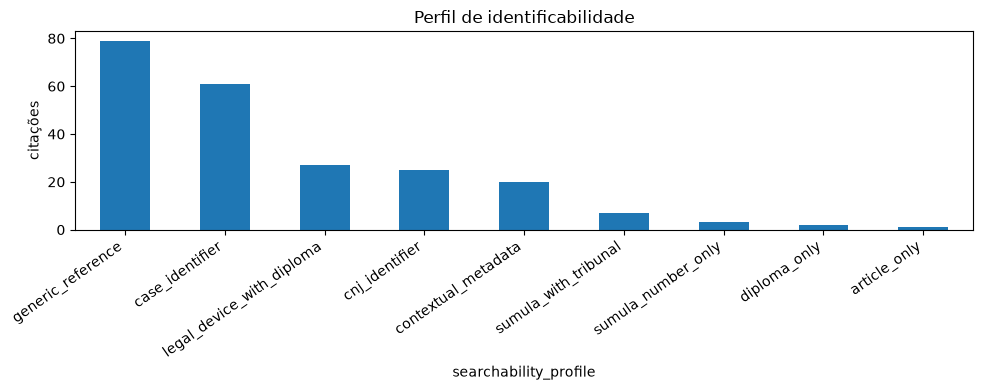

,parser_rule,citacoes,documentos,N1,N2,risco
3,lei_dispositivo_sem_diploma,1,1,1,0,low support
4,lei_referencia_geral,11,9,7,4,support distribuído
7,sumula_numerada,10,9,6,4,support distribuído
5,processo_cnj,25,10,17,8,support distribuído
1,jurisprudencia_tribunal_contextual,20,14,11,9,support distribuído
0,jurisprudencia_referencia_geral,46,19,15,31,support distribuído
2,lei_dispositivo_com_diploma,27,19,13,14,support distribuído
6,processo_ou_recurso_numerado,85,25,46,39,support distribuído


In [4]:
failures = []
for row in coverage.itertuples():
    if row.relevant and row.explicit_present and row.parsed < row.explicit_present:
        failures.append({'family': row.family, 'failure_type': f'{row.field}_explicit_not_parsed', 'quantidade': row.explicit_present - row.parsed})
failure_table = pd.DataFrame(failures, columns=['family', 'failure_type', 'quantidade'])
display(failure_table if not failure_table.empty else pd.DataFrame({'falhas': ['Nenhuma: todos os sinais explícitos cobertos pelos parsers experimentais']}))

noise_rows = []
for family, group in analysis.loc[analysis.nivel.eq('N2')].groupby('family'):
    spans = group.oracle_span
    mechanisms = {'newline_em_numero': spans.str.contains(r'\d[^\d]{0,2}\n[^\d]{0,2}\d', regex=True).sum(), 'espaco_em_numero': spans.str.contains(r'\d\s{2,}\d', regex=True).sum(), 'possivel_O0_l1_S5_em_numero': spans.str.contains(r'(?i)(?<=\d)[OIlS](?=\d)', regex=True).sum(), 'S5_em_sumula': spans.str.contains(r'(?i)\b5[úu]mula', regex=True).sum(), 'rn_por_m': 0}
    for mechanism, count in mechanisms.items():
        noise_rows.append({'mecanismo': mechanism, 'familias_afetadas': family, 'casos_afetados': int(count), 'impacto': 'registrar para tolerância local futura; sem repair nesta análise' if count else 'não observado por este indicador conservador'})
noise = pd.DataFrame(noise_rows, columns=['mecanismo', 'familias_afetadas', 'casos_afetados', 'impacto'])
display(noise if not noise.empty else pd.DataFrame({'ruído_N2': ['Nenhum mecanismo numérico detectado pelos indicadores conservadores']}))

tribunal_profile = analysis.tribunal_source.value_counts().rename_axis('tribunal_source').reset_index(name='quantidade')
display(tribunal_profile)
print('Inferência segura de tribunal: nenhuma aplicada. CNJ preserva o identificador, mas o segmento de justiça não foi promovido silenciosamente a um tribunal específico.')

def profile(row: pd.Series) -> str:
    if pd.notna(row.numero_family) and row.numero_family == 'cnj': return 'cnj_identifier'
    if pd.notna(row.numero_normalizado): return 'case_identifier'
    if pd.notna(row.sumula_numero) and pd.notna(row.tribunal): return 'sumula_with_tribunal'
    if pd.notna(row.sumula_numero): return 'sumula_number_only'
    if pd.notna(row.artigo) and pd.notna(row.diploma_normalizado): return 'legal_device_with_diploma'
    if pd.notna(row.law_number): return 'law_identifier'
    if pd.notna(row.diploma_normalizado): return 'diploma_only'
    if pd.notna(row.artigo): return 'article_only'
    if pd.notna(row.tribunal) and (pd.notna(row.relator_raw) or pd.notna(row.ano)): return 'contextual_metadata'
    return 'generic_reference'

analysis['searchability_profile'] = analysis.apply(profile, axis=1)
searchability = analysis.groupby('searchability_profile').agg(quantidade=('family', 'size'), familias=('family', lambda values: ', '.join(sorted(set(values))))).reset_index().sort_values('quantidade', ascending=False)
display(searchability)
analysis.searchability_profile.value_counts().plot.bar(figsize=(10, 4), title='Perfil de identificabilidade', ylabel='citações'); plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

support = analysis.assign(parser_rule=analysis.family).groupby('parser_rule').agg(citacoes=('gold_idx', 'size'), documentos=('documento_id', 'nunique'), N1=('nivel', lambda values: (values == 'N1').sum()), N2=('nivel', lambda values: (values == 'N2').sum())).reset_index()
support['risco'] = support.documentos.map(lambda value: 'low support' if value == 1 else 'support distribuído')
display(support.sort_values('documentos'))


## 5. Amostra auditável e implicações arquiteturais

A amostra mostra no máximo um N1 e um N2 por família. O contrato proposto é conceitual: uma estrutura comum pequena, com campos opcionais e provenance, preenchida por dispatch de parsers específicos por família. Não há `CitationParser` em produção nesta etapa.

In [5]:
audit = analysis.sort_values(['family', 'nivel', 'documento_id', 'inicio']).groupby(['family', 'nivel'], as_index=False).head(1).copy()
audit['extraido'] = audit.apply(lambda row: {key: row[key] for key in ('tribunal', 'classe_raw', 'numero_normalizado', 'uf', 'sumula_numero', 'artigo', 'paragrafo', 'inciso', 'alinea', 'diploma_normalizado', 'law_number', 'relator_raw', 'ano') if pd.notna(row[key])}, axis=1)
audit['ausente'] = audit.family.map(lambda family: ', '.join(FIELD_RELEVANCE[family]))
display(audit[['family', 'nivel', 'documento_id', 'oracle_span', 'extraido', 'tribunal_source', 'ausente']])

class_cross = pd.crosstab(analysis.family, analysis.classificacao).reindex(columns=['real', 'inventada', 'incompleta'], fill_value=0).reset_index()
display(class_cross)

print('Contrato conceitual mínimo: ParsedCitation(family, tipo, tribunal_raw, tribunal, tribunal_source, classe_raw, numero_raw, numero_normalizado, numero_family, uf_raw, uf, sumula_numero_raw, sumula_numero, artigo_raw, artigo, paragrafo_raw, paragrafo, inciso, alinea, diploma_raw, diploma_normalizado, law_number_raw, law_number, law_year, relator_raw, ano, year_source).')
print('Estratégia recomendada: dispatch por família → parser específico → ParsedCitation comum com campos opcionais; não uma regex universal.')
print('Fora do parser: existência no corpus, real/inventada/incompleta, id_canonico, desambiguação contra CaseIndex e decisão final de suficiência.')
print('Oracle-only: a aplicação aos spans detectados pela V2 não foi feita para não misturar qualidade de detection com parsing.')
print('SHA-256 depois:', sha256_file(DB_PATH))


,family,nivel,documento_id,oracle_span,extraido,tribunal_source,ausente
20,jurisprudencia_referencia_geral,N1,gen_n1_003,jurisprudência pacífica desta Corte,{},unknown,tribunal
125,jurisprudencia_referencia_geral,N2,gen_n2_002,5úmula 211 do STJ,{'tribunal': 'STJ'},explicit,tribunal
1,jurisprudencia_tribunal_contextual,N1,gen_n1_001,julgado do STF proferido em 2024 pela relatoria de Dias Toffoli,"{'tribunal': 'STF', 'relator_raw': 'relatoria de Dias Toffoli', 'ano': '2024'}",explicit,"tribunal, relator_raw, ano"
121,jurisprudencia_tribunal_contextual,N2,gen_n2_001,julgado do STJ proferido em 2023 pela relatoria dc Sérgio Kukinã,"{'tribunal': 'STJ', 'relator_raw': 'relatoria dc Sérgio Kukinã', 'ano': '2023'}",explicit,"tribunal, relator_raw, ano"
18,lei_dispositivo_com_diploma,N1,gen_n1_002,art. 1.134 da Lei nº\n13.105/2015,"{'artigo': '1134', 'diploma_normalizado': 'LEI Nº 13.105/2015', 'law_number': '13105'}",unknown,"artigo, paragrafo, inciso, alinea, diploma_normalizado, law_number"
129,lei_dispositivo_com_diploma,N2,gen_n2_002,"artigo 93, IX, da Constituição\nda República","{'artigo': '93', 'diploma_normalizado': 'CONSTITUIÇÃO'}",unknown,"artigo, paragrafo, inciso, alinea, diploma_normalizado, law_number"
61,lei_dispositivo_sem_diploma,N1,gen_n1_008,art. 477 da Consolidação das Leis do Trabalho,{'artigo': '477'},unknown,"artigo, paragrafo, inciso, alinea"
0,lei_referencia_geral,N1,gen_n1_001,normas\nde regência da matéria,{},unknown,"diploma_normalizado, law_number"
146,lei_referencia_geral,N2,gen_n2_004,dispositivo legal de regência,{},unknown,"diploma_normalizado, law_number"
3,processo_cnj,N1,gen_n1_001,AgInt 7557430-50.2018.7.00.0000/DF,{'numero_normalizado': '75574305020187000000'},unknown,"tribunal, numero_normalizado"


classificacao,family,real,inventada,incompleta
0,jurisprudencia_referencia_geral,13,10,23
1,jurisprudencia_tribunal_contextual,0,0,20
2,lei_dispositivo_com_diploma,13,14,0
3,lei_dispositivo_sem_diploma,1,0,0
4,lei_referencia_geral,0,0,11
5,processo_cnj,23,2,0
6,processo_ou_recurso_numerado,42,32,11
7,sumula_numerada,4,6,0


Contrato conceitual mínimo: ParsedCitation(family, tipo, tribunal_raw, tribunal, tribunal_source, classe_raw, numero_raw, numero_normalizado, numero_family, uf_raw, uf, sumula_numero_raw, sumula_numero, artigo_raw, artigo, paragrafo_raw, paragrafo, inciso, alinea, diploma_raw, diploma_normalizado, law_number_raw, law_number, law_year, relator_raw, ano, year_source).
Estratégia recomendada: dispatch por família → parser específico → ParsedCitation comum com campos opcionais; não uma regex universal.
Fora do parser: existência no corpus, real/inventada/incompleta, id_canonico, desambiguação contra CaseIndex e decisão final de suficiência.
Oracle-only: a aplicação aos spans detectados pela V2 não foi feita para não misturar qualidade de detection com parsing.


SHA-256 depois: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
